# Horizontal BP smoother on inferred ARGs

On a **true** ARG the per-tree posteriors are clean and a per-position deadband is near-optimal.
On an **inferred** (tsinfer) ARG, tree inference scatters spurious breakpoints a confidence
threshold cannot filter — the horizontal [BP smoother](../api/bp.bp_paint.html)
(`paint(smooth=True)`) suppresses them. Here we paint the same admixture on a tsinfer ARG with
and without smoothing.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm, colors
import tspaint
from tspaint.sim import SOURCE_A, SOURCE_B, ADMIXED

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.spines.top": False,
                     "axes.spines.right": False})

def admixture(n_admix=8, n_ref=8, L=2e6, T_admix=100, Ne=1000, T_split=5000, f_A=0.5,
              seed=1, infer=False, mutation_rate=4e-7):
    """Simulate admixture with known truth; return (ts, labels, queries, truth_states)."""
    ts = tspaint.simulate_admixture(n_admix=n_admix, n_ref=n_ref, sequence_length=L,
                                  recombination_rate=1e-8, random_seed=seed, Ne=Ne,
                                  T_admix=T_admix, T_split=T_split, f_A=f_A)
    pop = ts.tables.nodes.population
    name = {p: ts.population(p).metadata.get("name", str(p)) for p in range(ts.num_populations)}
    A = next(p for p, n in name.items() if n == SOURCE_A)
    B = next(p for p, n in name.items() if n == SOURCE_B)
    admix = next(p for p, n in name.items() if n == ADMIXED)
    sop = {A: 0, B: 1}
    labels = {int(s): sop[pop[s]] for s in ts.samples() if pop[s] in (A, B)}
    queries = [int(s) for s in ts.samples() if pop[s] == admix]
    truth = tspaint.metrics.map_truth({q: tspaint.local_ancestry_truth(ts)[0][q] for q in queries}, sop)
    work = ts
    if infer:
        work = tspaint.io.infer_tree_sequence(tspaint.io.add_mutations(ts, rate=mutation_rate,
                                                                   random_seed=seed))
    return work, labels, queries, truth

CMAP = "RdBu_r"   # red = ancestry A (state 0), blue = ancestry B (state 1)

def plot_painting(painting, truth, ts, title="", segments=None):
    """Soft posterior P(A) painted along the genome per query haplotype, with a thin truth
    strip beneath each. If `segments` (hard tracts) is given, draw those instead of soft."""
    qs = painting.queries
    L = ts.sequence_length
    sm = cm.ScalarMappable(norm=colors.Normalize(0, 1), cmap=CMAP)
    fig, ax = plt.subplots(figsize=(9, 0.42 * len(qs) + 1.2))
    for i, q in enumerate(qs):
        if segments is None:
            for seg in painting.posteriors[q]:
                ax.barh(i, seg.right - seg.left, left=seg.left, height=0.74,
                        color=sm.to_rgba(seg.posterior[0]), edgecolor="none")
        else:
            for (l, r, s) in segments[q]:
                ax.barh(i, r - l, left=l, height=0.74,
                        color=sm.to_rgba(1.0 if s == 0 else 0.0), edgecolor="none")
        for (l, r, s) in truth[q]:
            ax.barh(i - 0.46, r - l, left=l, height=0.13,
                    color=sm.to_rgba(1.0 if s == 0 else 0.0), edgecolor="none")
    ax.set_xlim(0, L); ax.set_ylim(-0.8, len(qs) - 0.2)
    ax.set_yticks(range(len(qs))); ax.set_yticklabels([f"hap {q}" for q in qs], fontsize=8)
    ax.set_xlabel("genomic position (bp)"); ax.set_title(title)
    cb = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.01)
    cb.set_label("P(ancestry A)")
    ax.text(0, len(qs) - 0.5, "thin strip below each = true ancestry", fontsize=7, color="0.4")
    fig.tight_layout()
    return fig

## Paint a tsinfer ARG, with and without smoothing

/var/folders/s6/srs8qkh52w1_h32d65z95tth0000gn/T/ipykernel_82217/254982599.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


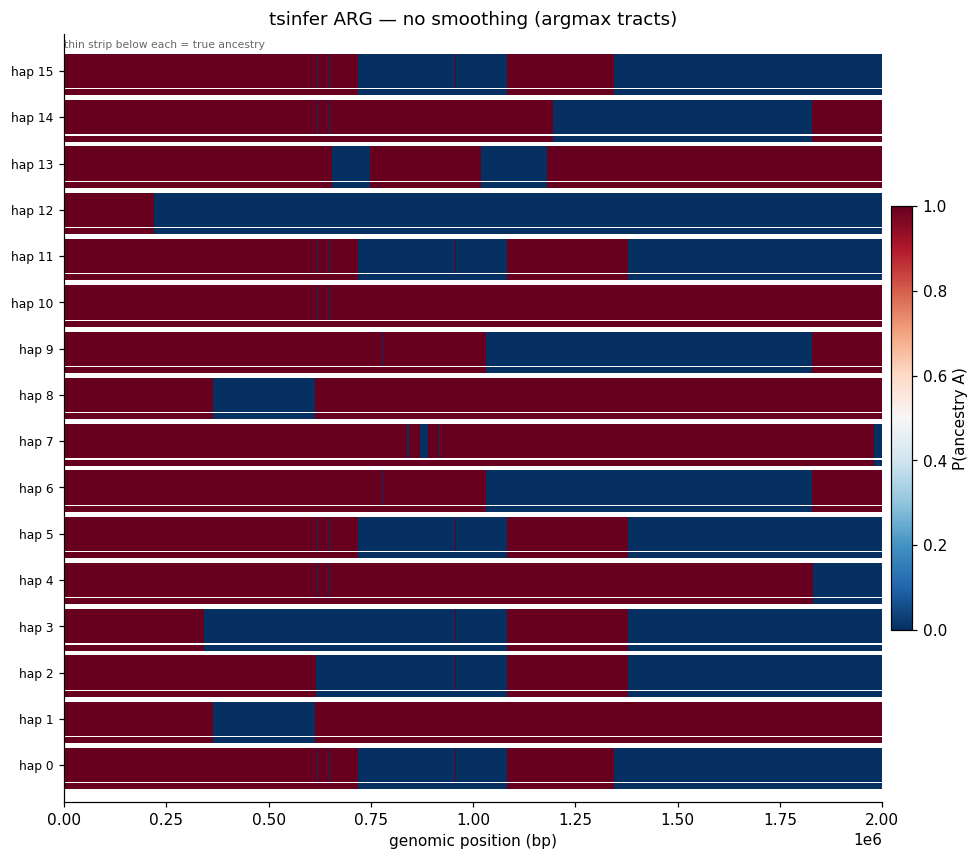

In [2]:
#| label: fig-bp-plain
#| fig-cap: "Hard tracts from a tsinfer ARG without smoothing: tree-inference noise fragments the tracts."
ts, labels, queries, truth = admixture(n_admix=8, n_ref=8, L=2e6, T_admix=200, seed=1, infer=True)
plain = tspaint.paint(ts, labels)
smooth = tspaint.paint(ts, labels, smooth=True)
fig = plot_painting(plain, truth, ts, "tsinfer ARG — no smoothing (argmax tracts)",
                    segments=plain.segments())
fig.show()

/var/folders/s6/srs8qkh52w1_h32d65z95tth0000gn/T/ipykernel_82217/3861043308.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


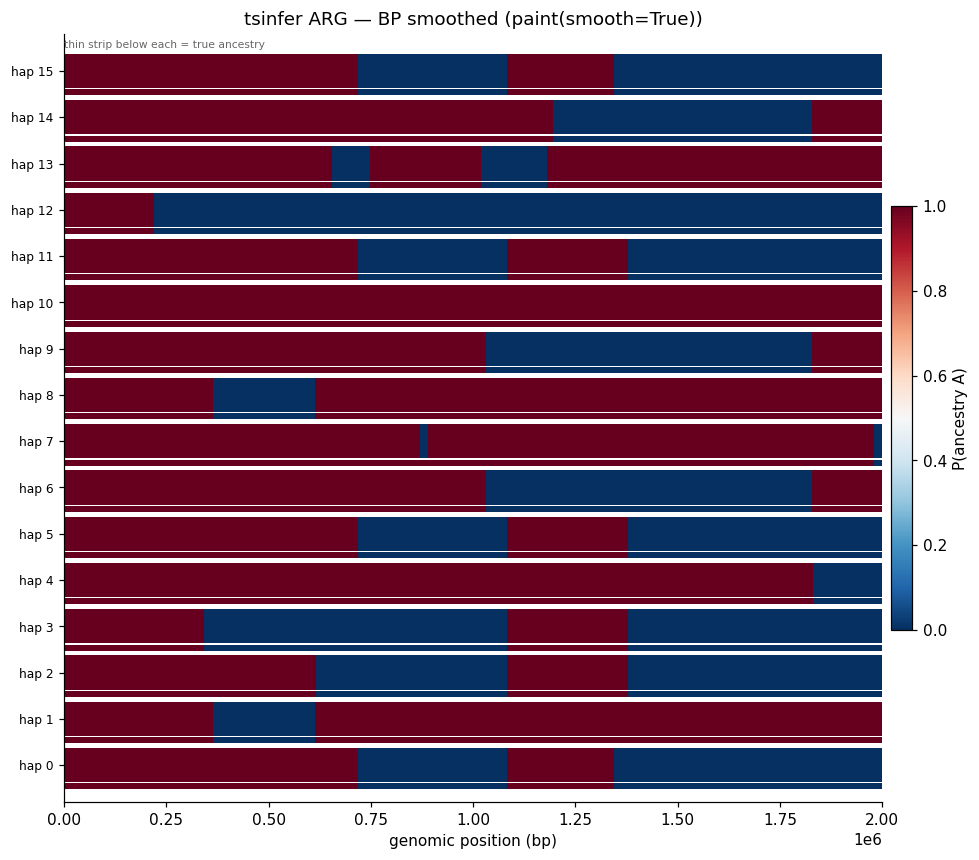

In [3]:
#| label: fig-bp-smooth
#| fig-cap: "The same tsinfer ARG with the horizontal BP smoother: spurious switches are suppressed, recovering the tract structure."
fig = plot_painting(smooth, truth, ts, "tsinfer ARG — BP smoothed (paint(smooth=True))", segments=smooth.segments())
fig.show()

## Quantified: segmentation F1, true vs inferred ARG

The BP smoother is redundant on the true ARG but wins decisively on inferred ARGs.

/var/folders/s6/srs8qkh52w1_h32d65z95tth0000gn/T/ipykernel_82217/879697762.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.tight_layout(); fig.show()


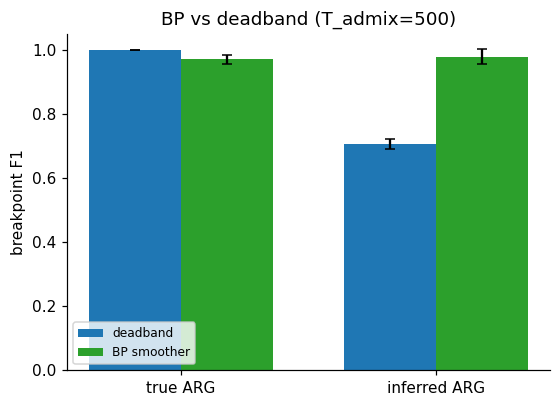

In [4]:
#| label: fig-bp
#| fig-cap: "Breakpoint F1 of the deadband vs the BP smoother on true and inferred ARGs: BP is redundant on the true ARG but wins on inferred ARGs."
res = {}
for infer in (False, True):
    r = tspaint.bp.bp_vs_deadband_experiment(T_admix=500, infer=infer, seeds=(1, 2, 3),
                                           n_admix=8, n_ref=8, sequence_length=2e6)
    res[("inferred" if infer else "true") + " ARG"] = r
fig, ax = plt.subplots(figsize=(5.2, 3.8))
x = np.arange(len(res)); w = 0.36
ax.bar(x - w/2, [v["deadband_f1"][0] for v in res.values()], w, label="deadband",
       yerr=[v["deadband_f1"][1] for v in res.values()], capsize=3, color="C0")
ax.bar(x + w/2, [v["bp_f1"][0] for v in res.values()], w, label="BP smoother",
       yerr=[v["bp_f1"][1] for v in res.values()], capsize=3, color="C2")
ax.set_xticks(x); ax.set_xticklabels(list(res)); ax.set_ylabel("breakpoint F1")
ax.set_ylim(0, 1.05); ax.set_title("BP vs deadband (T_admix=500)"); ax.legend(fontsize=8)
fig.tight_layout(); fig.show()